In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,ConfusionMatrixDisplay,classification_report
import matplotlib.pyplot as plt

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegressionCV,RidgeClassifierCV,LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC,LinearSVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
data = pd.read_csv('/content/smote_oversampled_data_combined.csv')

In [ ]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,target
0,1.163829,1.102033,1.052953,-0.295486,0.003213,0.635706,0.697178,0.299222,0.447130,-0.116795,...,0.415560,0.866687,0.940075,1.044973,1.684348,0.873129,0.920080,0.962860,1.673102,BROWSING
1,0.801999,0.825014,0.833114,1.380328,1.482641,0.159507,0.293392,0.571493,0.673884,-0.566262,...,0.325529,-0.950774,-0.952363,-0.952365,-0.615522,-0.949929,-0.951709,-0.951729,-0.615846,VOIP
2,0.790036,0.816289,0.826113,-0.316730,0.011037,0.708921,0.747983,0.220568,0.328144,0.082072,...,0.352285,0.948617,0.969976,0.990789,1.678997,0.901336,0.929803,0.983553,1.678064,CHAT
3,-0.835300,-1.631410,-1.470848,-1.486758,-1.267010,-1.612603,-1.432217,-1.601999,-1.402362,0.063958,...,-1.544860,-0.950774,-0.952363,-0.952365,-0.615522,-0.949929,-0.951709,-0.951729,-0.615846,FT
4,0.610166,0.675797,0.712883,-0.227320,0.025813,0.867001,0.888599,0.631207,0.738758,-0.658674,...,0.814472,1.088171,1.048471,1.022253,1.487179,1.106626,1.064328,1.038449,1.528804,BROWSING


In [ ]:
x  =data.iloc[:,:-1]
y = data.iloc[:,-1]


In [ ]:
y

,target
0,BROWSING
1,VOIP
2,CHAT
3,FT
4,BROWSING
...,...
55995,VOIP
55996,VOIP
55997,VOIP
55998,VOIP


In [ ]:
y.head()

,class1
0,BROWSING
1,BROWSING
2,BROWSING
3,BROWSING
4,BROWSING


In [ ]:
print(y.value_counts())


target
BROWSING     8000
VOIP         8000
CHAT         8000
FT           8000
P2P          8000
STREAMING    8000
MAIL         8000
Name: count, dtype: int64


In [ ]:
"""import pandas as pd
import numpy as np
from sklearn.utils import resample

# Agar X_train ek NumPy array hai
data = pd.DataFrame(x)
data['label'] = y

min_class_size = data['label'].value_counts().min()
print("Minor class sample count:", min_class_size)


balanced_data = (
    data.groupby('label', group_keys=False)
        .apply(lambda x: x.sample(min_class_size, random_state=42))
        .reset_index(drop=True)
)


X_balanced = balanced_data.drop('label', axis=1).values
y_balanced = balanced_data['label'].values


from sklearn.utils import shuffle
X_balanced, y_balanced = shuffle(X_balanced, y_balanced, random_state=42)

print(pd.Series(y_balanced).value_counts())

import pandas as pd

# Assuming you already have balanced_data DataFrame
balanced_data.to_csv("balanced_dataset.csv", index=False)

print("✅ Balanced dataset saved as balanced_dataset.csv")"""


Minor class sample count: 3514


/tmp/ipython-input-3208859421.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_class_size, random_state=42))


In [ ]:
st = StandardScaler()
x = st.fit_transform(x)

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

Machine Learning

In [ ]:
m1 = LogisticRegressionCV()
m2 = RidgeClassifierCV()
m3 = DecisionTreeClassifier()
m4 = SVC()
m5 = LinearSVC()
m6 = KNeighborsClassifier()

In [ ]:
m1 = m1.fit(x_train,y_train)
m2 = m2.fit(x_train,y_train,)
m3 = m3.fit(x_train,y_train)
m4 = m4.fit(x_train,y_train)
m5 = m5.fit(x_train,y_train)
m6 = m6.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
y1 = m1.predict(x_test)
y2 = m2.predict(x_test)
y3 = m3.predict(x_test)
y4 = m4.predict(x_test)
y5 = m5.predict(x_test)
y6 = m6.predict(x_test)

In [ ]:
accuracy_score1 = accuracy_score(y_test,y1) # LogisticRegressionCV
accuracy_score2 = accuracy_score(y_test,y2) # RidgeClassifierCV"""
accuracy_score3 = accuracy_score(y_test,y3) # DecisionTreeClassifier
accuracy_score4 = accuracy_score(y_test,y4) # SVC
accuracy_score5 = accuracy_score(y_test,y5) # LinearSVC
accuracy_score6 = accuracy_score(y_test,y6) # KNeighborsClassifier


print(f"accuracy_score1 LogisticRegressionCV: {accuracy_score1}")
print(f"accuracy_score2 RidgeClassifierCV: {accuracy_score2}")
print(f"accuracy_score3 DecisionTreeClassifier: {accuracy_score3}")
print(f"accuracy_score4 SVC: {accuracy_score4}")
print(f"accuracy_score5 LinearSVC: {accuracy_score5}")
print(f"accuracy_score6 KNeighborsClassifier: {accuracy_score6}")

accuracy_score1 LogisticRegressionCV: 0.6623214285714286
accuracy_score2 RidgeClassifierCV: 0.5777678571428572
accuracy_score3 DecisionTreeClassifier: 0.9436607142857143
accuracy_score4 SVC: 0.7878571428571428
accuracy_score5 LinearSVC: 0.6400892857142857
accuracy_score6 KNeighborsClassifier: 0.9380357142857143


Ensembel Learning

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestClassifier,VotingClassifier, StackingClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
import xgboost
import lightgbm
from catboost import CatBoostClassifier

In [ ]:
em1 = RandomForestClassifier()
em2 = AdaBoostClassifier()
em3 = GradientBoostingClassifier()
em4 = BaggingClassifier(n_estimators=100,n_jobs=-1)
em5 = ExtraTreesClassifier()
em6 = HistGradientBoostingClassifier()
em9 = xgboost.XGBClassifier()
em10 = lightgbm.LGBMClassifier(n_jobs=-1)
em11 = CatBoostClassifier()

In [ ]:
em7= VotingClassifier(estimators=[('m3',m3),('m6',m6),('em1',em1)],voting='hard',n_jobs=-1)
em12= VotingClassifier(estimators=[('em1',em1),('em4',em4),('em5',em5),('em6',em6),('em9',em9)],voting='hard',n_jobs=-1)
em13= VotingClassifier(estimators=[('em1',em1),('em4',em4),('em5',em5),('em6',em6),('em9',em9),('m3',m3),('m6',m6)],voting='hard',n_jobs=-1)
em8 = StackingClassifier(estimators=[('m3',m3),('m6',m6),('em1',em1)],final_estimator=m1,n_jobs=-1)
em14 = StackingClassifier(estimators=[('em1',em1),('em4',em4),('em5',em5),('em6',em6),('em9',em9)],final_estimator=m1,n_jobs=-1)
em15 = StackingClassifier(estimators=[('em1',em1),('em4',em4),('em5',em5),('em6',em6),('em9',em9),('m3',m3),('m6',m6)],final_estimator=m1,n_jobs=-1)

In [ ]:
em1 = em1.fit(x_train,y_train)
em2 = em2.fit(x_train,y_train)
em3 = em3.fit(x_train,y_train)
em4 = em4.fit(x_train,y_train)
em5 = em5.fit(x_train,y_train)
em6 = em6.fit(x_train,y_train)
em7 = em7.fit(x_train,y_train)
em8 = em8.fit(x_train,y_train)
em9 = em9.fit(x_train,y_train)
em10 = em10.fit(x_train,y_train)
em11 = em11.fit(x_train,y_train)
em12 = em12.fit(x_train,y_train)
em13 = em13.fit(x_train,y_train)
em14 = em14.fit(x_train,y_train)
em15 = em15.fit(x_train,y_train)

Learning rate set to 0.096059
0:	learn: 1.7632501	total: 345ms	remaining: 5m 44s
1:	learn: 1.6388440	total: 666ms	remaining: 5m 32s
2:	learn: 1.5363399	total: 985ms	remaining: 5m 27s
3:	learn: 1.4551930	total: 1.22s	remaining: 5m 4s
4:	learn: 1.3856169	total: 1.41s	remaining: 4m 40s
5:	learn: 1.3252999	total: 1.69s	remaining: 4m 40s
6:	learn: 1.2697621	total: 1.92s	remaining: 4m 32s
7:	learn: 1.2339549	total: 2.09s	remaining: 4m 19s
8:	learn: 1.1978675	total: 2.32s	remaining: 4m 15s
9:	learn: 1.1597774	total: 2.54s	remaining: 4m 11s
10:	learn: 1.1296414	total: 2.76s	remaining: 4m 8s
11:	learn: 1.0912632	total: 2.92s	remaining: 4m
12:	learn: 1.0742406	total: 3.05s	remaining: 3m 51s
13:	learn: 1.0462937	total: 3.22s	remaining: 3m 46s
14:	learn: 1.0267080	total: 3.41s	remaining: 3m 44s
15:	learn: 1.0060645	total: 3.56s	remaining: 3m 39s
16:	learn: 0.9824939	total: 3.69s	remaining: 3m 33s
17:	learn: 0.9635872	total: 3.85s	remaining: 3m 30s
18:	learn: 0.9443374	total: 4.02s	remaining: 3m 27

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
for name, _ in em7.estimators:
    model = em7.named_estimators_[name]
    y_pred = model.predict(x_test)
    print(name, y_pred.shape)

In [ ]:
ey1 = em1.predict(x_test)
ey2 = em2.predict(x_test)
ey3 = em3.predict(x_test)
ey4 = em4.predict(x_test)
ey5 = em5.predict(x_test)
ey6 = em6.predict(x_test)
ey7 = em7.predict(x_test)
ey8 = em8.predict(x_test)
ey9 = em9.predict(x_test)
ey10 = em10.predict(x_test)
ey11 = em11.predict(x_test)
ey12 = em12.predict(x_test)
ey13 = em13.predict(x_test)
ey14 = em14.predict(x_test)
ey15 = em15.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
e_accuracy_score1 = accuracy_score(y_test,ey1) # RandomForestClassifier
e_accuracy_score2 = accuracy_score(y_test,ey2) # AdaBoostClassifier
e_accuracy_score3 = accuracy_score(y_test,ey3) # GradientBoost
e_accuracy_score4 = accuracy_score(y_test,ey4) # BaggingClassifier
e_accuracy_score5 = accuracy_score(y_test,ey5) # Extra
e_accuracy_score6 = accuracy_score(y_test,ey6) # HistGradient
e_accuracy_score7 = accuracy_score(y_test,ey7)
e_accuracy_score8 = accuracy_score(y_test,ey8)
e_accuracy_score9 = accuracy_score(y_test,ey9) # xgboost
e_accuracy_score10 = accuracy_score(y_test,ey10) # lightgbm
e_accuracy_score11 = accuracy_score(y_test,ey11) # catboost"""
e_accuracy_score12 = accuracy_score(y_test,ey12)
e_accuracy_score13 = accuracy_score(y_test,ey13)
e_accuracy_score14 = accuracy_score(y_test,ey14)
e_accuracy_score15 = accuracy_score(y_test,ey15)

In [ ]:
print(f"e_accuracy_score1 RandomForestClassifier:         {e_accuracy_score1}")
print(f"e_accuracy_score2 AdaBoostClassifier:             {e_accuracy_score2}")
print(f"e_accuracy_score3 GradientBoostingClassifier:     {e_accuracy_score3}")
print(f"e_accuracy_score4 BaggingClassifier:              {e_accuracy_score4}")
print(f"e_accuracy_score5 ExtraTreesClassifier:           {e_accuracy_score5}")
print(f"e_accuracy_score6 HistGradientBoostingClassifier: {e_accuracy_score6}")
print(f"e_accuracy_score7 upper VotingClassifier:         {e_accuracy_score7}")
print(f"e_accuracy_score8 upper StackingClassifier:       {e_accuracy_score8}")
print(f"e_accuracy_score9 xgboost:                        {e_accuracy_score9}")
print(f"e_accuracy_score10 lightgbm:                      {e_accuracy_score10}")
print(f"e_accuracy_score11 CatBoostClassifier:            {e_accuracy_score11}")
print(f"e_accuracy_score12 lower VotingClassifier:        {e_accuracy_score12}")
print(f"e_accuracy_score13 upper+ower VotingClassifier:   {e_accuracy_score13}")
print(f"e_accuracy_score14 lower StackingClassifier:      {e_accuracy_score14}")
print(f"e_accuracy_score15 upper+lower StackingClassifier:{e_accuracy_score15}")

e_accuracy_score1 RandomForestClassifier:         0.9572321428571429
e_accuracy_score2 AdaBoostClassifier:             0.5358035714285714
e_accuracy_score3 GradientBoostingClassifier:     0.8773214285714286
e_accuracy_score4 BaggingClassifier:              0.9591071428571428
e_accuracy_score5 ExtraTreesClassifier:           0.9575892857142857
e_accuracy_score6 HistGradientBoostingClassifier: 0.9504464285714286
e_accuracy_score7 upper VotingClassifier:         0.9564285714285714
e_accuracy_score8 upper StackingClassifier:       0.9604464285714286
e_accuracy_score9 xgboost:                        0.9552678571428571
e_accuracy_score10 lightgbm:                      0.95
e_accuracy_score11 CatBoostClassifier:            0.9366071428571429
e_accuracy_score12 lower VotingClassifier:        0.960625
e_accuracy_score13 upper+ower VotingClassifier:   0.961875
e_accuracy_score14 lower StackingClassifier:      0.9630357142857143
e_accuracy_score15 upper+lower StackingClassifier:0.9626785714285714

multi layer preceptron (MLP)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 359ms/step - accuracy: 0.2017 - loss: 1.8866 - val_accuracy: 0.4084 - val_loss: 1.6823
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4277 - loss: 1.5914 - val_accuracy: 0.5387 - val_loss: 1.3277
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5758 - loss: 1.2561 - val_accuracy: 0.6385 - val_loss: 1.0942
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6350 - loss: 1.0584 - val_accuracy: 0.6639 - val_loss: 0.9541
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6674 - loss: 0.9421 - val_accuracy: 0.6851 - val_loss: 0.8864
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6901 - loss: 0.8786 - val_accuracy: 0.7041 - val_loss: 0.8307
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7007 - loss: 0.8303 - val_accuracy: 0.7140 - val_loss: 0.7935
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7139 - loss: 0.7937 - val_accuracy: 0.7297 - val_loss

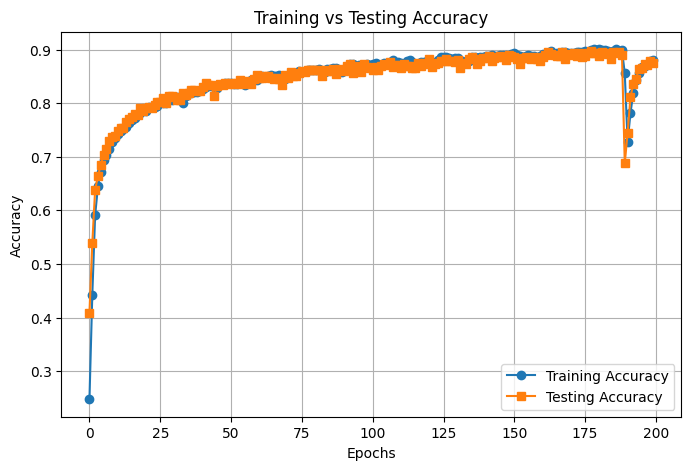

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt


# 🔹 Step 4: Define MLP model (Sequential)
model = Sequential([
    layers.Input(shape=(23,)),
    layers.Dense(512),
    layers.ReLU(),
    layers.Dense(256),
    layers.ReLU(),
    layers.Dense(128),
    layers.ReLU(),
    layers.Dense(64),
    layers.ReLU(),
    layers.Dense(32),
    layers.ReLU(),
    layers.Dense(16),
    layers.ReLU(),
    layers.Dense(7, activation='softmax')  # 7 classes
])

# Step 5: Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Step 6: Train model
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=200,
    batch_size=5000,
    #class_weight=class_weights_dict,
    verbose=1
)

# 🔹 Step 7: Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# 🔹 Step 8: Predictions
y_pred = np.argmax(model.predict(x_test), axis=1)

# 🔹 Step 9: Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 🔹 Step 10: Plot accuracy curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy', marker='s')
plt.title("Training vs Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Autoint (Automatic feature intrection with feature intrection)

Epoch [1/100] | Loss: 1.9562 | Train Acc: 0.149 | Test Acc: 0.147
Epoch [2/100] | Loss: 1.9317 | Train Acc: 0.149 | Test Acc: 0.147
Epoch [3/100] | Loss: 1.9141 | Train Acc: 0.149 | Test Acc: 0.147
Epoch [4/100] | Loss: 1.8945 | Train Acc: 0.145 | Test Acc: 0.142
Epoch [5/100] | Loss: 1.8732 | Train Acc: 0.304 | Test Acc: 0.306
Epoch [6/100] | Loss: 1.8493 | Train Acc: 0.362 | Test Acc: 0.366
Epoch [7/100] | Loss: 1.8219 | Train Acc: 0.399 | Test Acc: 0.403
Epoch [8/100] | Loss: 1.7914 | Train Acc: 0.420 | Test Acc: 0.421
Epoch [9/100] | Loss: 1.7597 | Train Acc: 0.444 | Test Acc: 0.444
Epoch [10/100] | Loss: 1.7298 | Train Acc: 0.448 | Test Acc: 0.448
Epoch [11/100] | Loss: 1.7048 | Train Acc: 0.455 | Test Acc: 0.455
Epoch [12/100] | Loss: 1.6816 | Train Acc: 0.465 | Test Acc: 0.464
Epoch [13/100] | Loss: 1.6563 | Train Acc: 0.486 | Test Acc: 0.486
Epoch [14/100] | Loss: 1.6280 | Train Acc: 0.531 | Test Acc: 0.527
Epoch [15/100] | Loss: 1.5985 | Train Acc: 0.516 | Test Acc: 0.513
Epoc

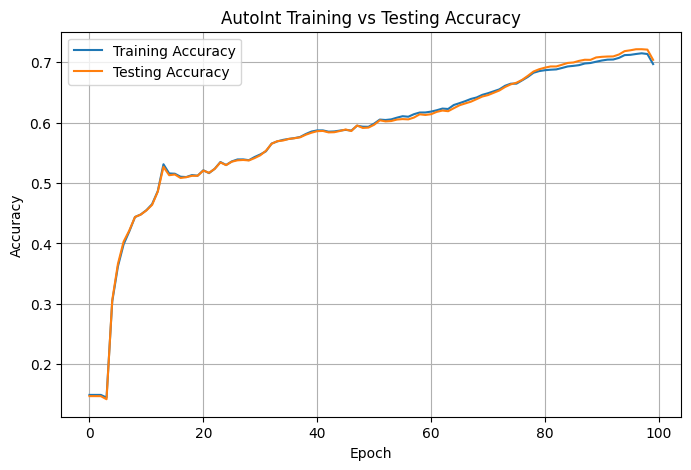

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# 🔹 Step 2: Convert numpy -> torch tensors
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# -------------------------------
# 🔹 2. Model Hyperparameters
# -------------------------------
input_dim = 23
embed_dim = 128
num_heads = 4
num_blocks = 2
mlp_hidden = 64
num_classes = 7

# -------------------------------
# 🔹 3. Build AutoInt Model (no class)
# -------------------------------
embed_layer = nn.Linear(input_dim, embed_dim)
att_blocks = nn.ModuleList([
    nn.TransformerEncoderLayer(
        d_model=embed_dim,
        nhead=num_heads,
        dim_feedforward=embed_dim,
        batch_first=True,
        activation='relu',
        norm_first=True
    )
    for _ in range(num_blocks)
])

mlp = nn.Sequential(
    nn.Linear(embed_dim, mlp_hidden),
    nn.ReLU(),
    nn.Linear(mlp_hidden,32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, num_classes)  # multi-class output, changed input dimension to 16
)

# -------------------------------
# 🔹 4. Training Setup
# -------------------------------
optimizer = torch.optim.Adam(
    list(embed_layer.parameters()) +
    list(att_blocks.parameters()) +
    list(mlp.parameters()), lr=1e-3
)
criterion = nn.CrossEntropyLoss()

num_epochs = 100
train_accs, test_accs = [], []

# -------------------------------
# 🔹 5. Training Loop
# -------------------------------
for epoch in range(num_epochs):
    # ---- Train Mode ----
    embed_layer.train(); mlp.train()
    for blk in att_blocks: blk.train()

    # Forward pass
    z = embed_layer(x_train).unsqueeze(1)
    for blk in att_blocks:
        z = blk(z)
    z = z.mean(dim=1)
    outputs = mlp(z)

    loss = criterion(outputs, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ---- Evaluate ----
    embed_layer.eval(); mlp.eval()
    for blk in att_blocks: blk.eval()

    with torch.no_grad():
        # Training accuracy
        z = embed_layer(x_train).unsqueeze(1)
        for blk in att_blocks: z = blk(z)
        z = z.mean(dim=1)
        train_pred = torch.argmax(mlp(z), dim=1)
        train_acc = accuracy_score(y_train, train_pred)

        # Testing accuracy
        z = embed_layer(x_test).unsqueeze(1)
        for blk in att_blocks: z = blk(z)
        z = z.mean(dim=1)
        test_pred = torch.argmax(mlp(z), dim=1)
        test_acc = accuracy_score(y_test, test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {loss.item():.4f} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

# -------------------------------
# 🔹 6. Plot Accuracy Graph
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(train_accs, label='Training Accuracy')
plt.plot(test_accs, label='Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('AutoInt Training vs Testing Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Epoch 1/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.6026 - loss: 1.1406 - val_accuracy: 0.7311 - val_loss: 0.7377
Epoch 2/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7319 - loss: 0.7384 - val_accuracy: 0.7652 - val_loss: 0.6481
Epoch 3/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7586 - loss: 0.6590 - val_accuracy: 0.7835 - val_loss: 0.6065
Epoch 4/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7836 - loss: 0.6002 - val_accuracy: 0.7905 - val_loss: 0.5815
Epoch 5/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7913 - loss: 0.5726 - val_accuracy: 0.8002 - val_loss: 0.5513
Epoch 6/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8047 - loss: 0.5414 - val_accuracy: 0.8139 - val_loss: 0.5123
Epoch 7/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8151 - loss: 0.5116 - val_accuracy: 0.8187 - val_loss: 0.5161
Epoch 8/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8175 - loss: 0.5020 - val_accuracy: 0

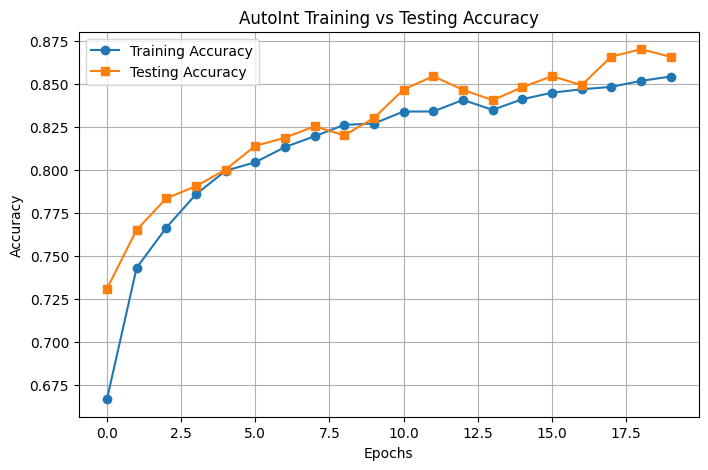

In [ ]:
# ✅ AutoInt (TensorFlow Sequential Implementation)
import tensorflow as tf
from tensorflow.keras import layers, Sequential, Model
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt


# -------------------------------
# 🔹 Step 2: Model Hyperparameters
# -------------------------------
input_dim = 23
embed_dim = 128
num_heads = 6
num_blocks = 3
mlp_hidden = 64
num_classes = 7
dropout_rate = 0.1

# -------------------------------
# 🔹 Step 3: Build AutoInt Model (No Class)
# -------------------------------

# Input layer
inputs = layers.Input(shape=(input_dim,))

# Embedding (dense projection of features)
x = layers.Dense(embed_dim)(inputs)
x = layers.Reshape((1, embed_dim))(x) # Use Keras Reshape layer


# Multi-Head Self-Attention Blocks
for _ in range(num_blocks):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    # Feedforward sublayer
    ffn = Sequential([
        layers.Dense(embed_dim, activation='relu'),
        layers.Dense(embed_dim)
    ])
    ffn_output = ffn(x)
    x = layers.Add()([x, ffn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

# Global Average Pooling across the sequence dimension
x = layers.MaxPool1D(1)(x) # Changed to MaxPool1D with pool_size 1 since seq_len is 1

# MLP layers
x = layers.Dense(mlp_hidden, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)
x = layers.Flatten()(x) # Flatten the output of the last dense layer


# Output layer
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Build model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# -------------------------------
# 🔹 Step 4: Compile Model
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 🔹 Step 5: Train Model
# -------------------------------
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=100,
    verbose=1
)

# -------------------------------
# 🔹 Step 6: Evaluate
# -------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# -------------------------------
# 🔹 Step 7: Predictions
# -------------------------------
y_pred = np.argmax(model.predict(x_test), axis=1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -------------------------------
# 🔹 Step 8: Plot Accuracy
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy', marker='s')
plt.title("AutoInt Training vs Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#convolution layer


In [ ]:
# --- Imports ---
import tensorflow as tf
from tensorflow.keras import layers, losses, optimizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits   # 10 classes example dataset
import numpy as np


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# ---------------- Data setup ----------------
num_classes = len(np.unique(y))  # e.g. 10 classes

# Reshape for Conv1D
X_train = np.expand_dims(x_train, axis=-1)
X_test = np.expand_dims(x_test, axis=-1)

# ---------------- Sequential Model ----------------
model = models.Sequential([
    layers.Conv1D(128, 3, padding='same', activation='relu', input_shape=(X_train.shape[1], 1)),
    layers.Conv1D(64, 3, padding='same', activation='relu'),
    layers.Conv1D(32, 3, padding='same', activation='relu'),
    layers.Conv1D(16, 3, padding='same', activation='relu'),
   # layers.BatchNormalization(),

    #layers.MaxPool1D(),
    layers.Flatten(), # Add this layer to flatten the output

    # 👇 Add extra Dense layers for complexity
    layers.Dense(128, activation='relu'),
    #layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    #layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    # Final output layer
    layers.Dense(num_classes, activation='softmax')
])

# ---------------- Compile model ----------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------- Train model ----------------
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=5000,
    validation_data=(X_test, y_test),
    verbose=1
)

# ---------------- Evaluate ----------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.1944 - loss: 1.9198 - val_accuracy: 0.2689 - val_loss: 1.8036
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3238 - loss: 1.7394 - val_accuracy: 0.4103 - val_loss: 1.5486
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4135 - loss: 1.4928 - val_accuracy: 0.5000 - val_loss: 1.3131
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5226 - loss: 1.2759 - val_accuracy: 0.5929 - val_loss: 1.1503
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6054 - loss: 1.1195 - val_accuracy: 0.6202 - val_loss: 1.0184
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6341 - loss: 1.0004 - val_accuracy: 0.6751 - val_loss: 0.9147
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6790 - loss: 0.9086 - val_accuracy: 0.6964 - val_loss: 0.8596
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6937 - loss: 0.8561 - val_accuracy: 0.7166 - val_loss: 

In [ ]:
model.save("cnn1d_base_model.h5")
print("✅ Base model saved as cnn1d_base_model.h5")

✅ Base model saved as cnn1d_base_model.h5


# 2 step learning  (Learning + fineuning)

In [ ]:
z = pd.read_csv("/content/new_good_distributed_mini_data.csv")
z1  =data.iloc[:,:-1]
z2 = data.iloc[:,-1]

print(z2.value_counts())

st = StandardScaler()
z1 = st.fit_transform(z1)

le = LabelEncoder()
z2 = le.fit_transform(z2)

x_train,x_test,y_train,y_test = train_test_split(z1,z2,test_size=0.1,random_state=42)

class1
BROWSING     30000
VOIP         17637
FT           13383
P2P          10830
CHAT          8183
MAIL          6252
STREAMING     3514
Name: count, dtype: int64


In [ ]:
z1  =data.iloc[:,:-1]
z2 = data.iloc[:,-1]

In [ ]:
print(z2.value_counts())

st = StandardScaler()
z1 = st.fit_transform(z1)

le = LabelEncoder()
z2 = le.fit_transform(z2)

class1
BROWSING     30000
VOIP         17637
FT           13383
P2P          10830
CHAT          8183
MAIL          6252
STREAMING     3514
Name: count, dtype: int64


In [ ]:
model = tf.keras.models.load_model("cnn1d_base_model.h5")
print("✅ Model loaded successfully")

✅ Model loaded successfully


In [ ]:
for layer in model.layers[:-3]:  # Freeze all except last 2 layers
    print(layer)
    layer.trainable = False

<Conv1D name=conv1d_9, built=True>
<Conv1D name=conv1d_10, built=True>
<Conv1D name=conv1d_11, built=True>
<Conv1D name=conv1d_12, built=True>
<Flatten name=flatten_2, built=True>
<Dense name=dense_12, built=True>
<Dense name=dense_13, built=True>


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
# ---------------- Build new model ----------------
model1 = Sequential([
    model,
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    #Dropout(0.1),
    Dense(16, activation='relu'),
    Dense(7, activation='softmax')   # ✅ 7 classes
])

In [ ]:
# Step 1: Compile model correctly for integer labels
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # ✅ sparse version
    metrics=['accuracy']
)

# Step 2: Fine-tune on your mini balanced dataset
model1.fit(
    z1, z2,
    epochs=5,
    validation_split=0.1,
    batch_size=5000,
    verbose=1
)

Epoch 1/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9183 - loss: 0.2422 - val_accuracy: 0.9296 - val_loss: 0.2565
Epoch 2/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9156 - loss: 0.2435 - val_accuracy: 0.9355 - val_loss: 0.2364
Epoch 3/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9187 - loss: 0.2385 - val_accuracy: 0.9352 - val_loss: 0.2383
Epoch 4/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9191 - loss: 0.2373 - val_accuracy: 0.9366 - val_loss: 0.2304
Epoch 5/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9176 - loss: 0.2414 - val_accuracy: 0.9450 - val_loss: 0.2034


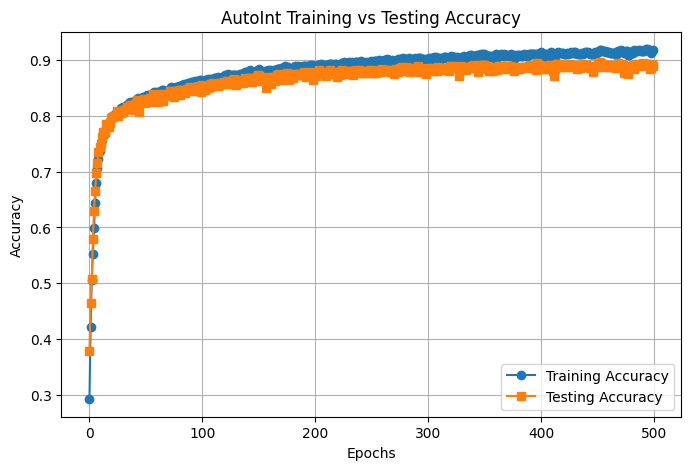

In [ ]:
# -------------------------------
# 🔹 Step 8: Plot Accuracy
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy', marker='s')
plt.title("AutoInt Training vs Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 1D-cnn + xg boost Hybride model

In [ ]:
z = pd.read_csv("/content/new_good_distributed_mini_data.csv")
z1  =data.iloc[:,:-1]
z2 = data.iloc[:,-1]

print(z2.value_counts())

st = StandardScaler()
z1 = st.fit_transform(z1)

le = LabelEncoder()
z2 = le.fit_transform(z2)

class1
BROWSING     30000
VOIP         17637
FT           13383
P2P          10830
CHAT          8183
MAIL          6252
STREAMING     3514
Name: count, dtype: int64


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(z1,z2,test_size=0.1,random_state=42)

In [ ]:
from tensorflow.keras.models import load_model

# Load pre-trained CNN1D model
cnn_model = load_model("/content/cnn1d_base_model.h5")
cnn_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 23, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 23, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 23, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 23, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 368)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        47,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,097 (355.85 KB)

 Trainable params: 91,095 (355.84 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
cnn_model.build(input_shape=(None, X_train.shape[1], 1))

from tensorflow.keras.models import Model
feature_extractor = Model(
    inputs=cnn_model.layers[0].input,
    outputs=cnn_model.layers[-2].output
)


In [ ]:
X_train_features = feature_extractor.predict(x_train)
X_test_features  = feature_extractor.predict(x_test)


2526/2526 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
x_test.shape

(8980, 23)

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.002,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    optimizer='adam'
)

xgb_model.fit(X_train_features, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:05:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "optimizer" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.002, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = xgb_model.predict(X_test_features)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[2930   28   56    3   21    3    6]
 [ 176  474   73   30   37    0    9]
 [ 118   53  968   69  114    9   11]
 [   9    2   15  584    8    0    0]
 [  40   11   48    2  983    2   12]
 [  35    1   12    1   51  289    3]
 [  13    4    8    1   21    0 1637]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      3047
           1       0.83      0.59      0.69       799
           2       0.82      0.72      0.77      1342
           3       0.85      0.94      0.89       618
           4       0.80      0.90      0.84      1098
           5       0.95      0.74      0.83       392
           6       0.98      0.97      0.97      1684

    accuracy                           0.88      8980
   macro avg       0.87      0.83      0.85      8980
weighted avg       0.88      0.88      0.87      8980



#After Statical Analysis (Yeo-Johnson transformation)

#Huging face transformer model

In [ ]:
!pip install tabstar

#tabstar Transformer

In [ ]:
from importlib.resources import files
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from tabstar.tabstar_model import TabSTARClassifier

x = pd.read_csv("/content/new_good_distributed_seneriyo_A_data.csv")
y = x.pop('class1')

#x,y should be in data frame for model.fit


❗ Warning: 8 CPU devices requested, but only 2 available.


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1)
# For regression tasks, replace `TabSTARClassifier` with `TabSTARRegressor`.
tabstar = TabSTARClassifier(max_epochs=4)
tabstar.fit(x_train, y_train)

🖥️ Using device: cuda:0
🤩 Loading pretrained model version: alana89/TabSTAR


config.json:   0%|          | 0.00/535 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/189M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

...

Epoch 2 || Train 0.5644 || Val 0.5240 || Metric 0.9686 🥇



Epochs:  75%|███████▌  | 3/4 [09:02<03:00, 180.74s/it]

Epoch 3 || Train 0.4833 || Val 0.4799 || Metric 0.9736 🥇



Batches: 100%|██████████| 1248/1248 [03:03<00:00,  7.01it/s]
                                                      

Epoch 4 || Train 0.4627 || Val 0.4798 || Metric 0.9737 🥇


In [ ]:
metric = tabstar.score(X=x_test, y=y_test)
print(f"AUC: {metric:.4f} ")

AUC: 0.9760 


#FTT Transformr

In [ ]:
data = pd.read_csv('/content/new_good_distributed_data.csv')

In [ ]:
x  =data.iloc[:,:-1]
y = data.iloc[:,-1]

In [ ]:
st = StandardScaler()
x = st.fit_transform(x)

le = LabelEncoder()
y = le.fit_transform(y)

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
y

array([0, 0, 0, ..., 0, 0, 7])

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

# FT-Transformer model
class FTTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=128, num_heads=4, num_layers=3, dropout=0.1):
        super(FTTransformer, self).__init__()
        self.projection = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, dropout=dropout)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = self.projection(x).unsqueeze(1)
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.head(x)

# Train and evaluate
def train_model(model, train_loader, test_loader, epochs=10, lr=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            preds = model(batch_X).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    print(f"FT-Transformer Test Accuracy: {accuracy_score(all_labels, all_preds) * 100:.2f}%")

# Data preparation
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

model = FTTransformer(input_dim=X_train.shape[1], num_classes=7)
train_model(model, train_loader, test_loader)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/10], Loss: 0.8734
Epoch [2/10], Loss: 0.5116
Epoch [3/10], Loss: 1.0448
Epoch [4/10], Loss: 0.4451
Epoch [5/10], Loss: 0.6746
Epoch [6/10], Loss: 0.4945
Epoch [7/10], Loss: 0.8081
Epoch [8/10], Loss: 0.5012
Epoch [9/10], Loss: 0.4730
Epoch [10/10], Loss: 0.4683
FT-Transformer Test Accuracy: 82.26%


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pickle

from tabstar.tabstar_model import TabSTARClassifier

# ---------------------------------------------------------
# Load Dataset
# ---------------------------------------------------------
df = pd.read_csv("/content/new_good_distributed_seneriyo_A_data.csv")

# Encode string labels into numeric
df['class1'] = df['class1'].astype('category')
df['label'] = df['class1'].cat.codes   # NEW numeric labels

label_mapping = dict(enumerate(df['class1'].cat.categories))
# Save mapping for inverse transform later
print("Label Mapping:", label_mapping)

y = df['label']
X = df.drop(columns=['class1', 'label'])

# ---------------------------------------------------------
# Train–Test Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# ---------------------------------------------------------
# Model Initialization
# ---------------------------------------------------------
tabstar = TabSTARClassifier(max_epochs=4)

# ---------------------------------------------------------
# Train Model
# ---------------------------------------------------------
history = tabstar.fit(X_train, y_train)

# ---------------------------------------------------------
# Predict
# ---------------------------------------------------------
y_pred = tabstar.predict(X_test)

# Convert numeric prediction → string label
y_pred_labels = [label_mapping[i] for i in y_pred]
y_test_labels = [label_mapping[i] for i in y_test]

# ---------------------------------------------------------
# Classification Report
# ---------------------------------------------------------
print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test_labels, y_pred_labels))

"""# ---------------------------------------------------------
# Save Model + Mapping
# ---------------------------------------------------------
save_obj = {
    "model": tabstar,
    "label_mapping": label_mapping
}

with open("/content/tabstar_model.pkl", "wb") as f:
    pickle.dump(save_obj, f)

print("\nModel saved successfully!")"""


❗ Warning: 8 CPU devices requested, but only 2 available.


/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


Label Mapping: {0: 'BROWSING', 1: 'CHAT', 2: 'FT', 3: 'MAIL', 4: 'P2P', 5: 'STREAMING', 6: 'VOIP'}
🖥️ Using device: cuda:0
🤩 Loading pretrained model version: alana89/TabSTAR


Batches: 100%|██████████| 408/408 [01:09<00:00,  7.54it/s]
                                                          

Epoch 1 || Train 0.9470 || Val 0.6827 || Metric 0.9497 🥇


...

Epoch 3 || Train 0.5406 || Val 0.4888 || Metric 0.9692 🥇


Batches: 100%|██████████| 408/408 [00:58<00:00,  6.87it/s]
                                                     

Epoch 4 || Train 0.5125 || Val 0.4888 || Metric 0.9691 😓 [1/5 worse]



=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    BROWSING       0.86      0.92      0.89      1000
        CHAT       0.61      0.53      0.57       284
          FT       0.77      0.59      0.67       470
        MAIL       0.75      0.93      0.83       244
         P2P       0.77      0.81      0.79       342
   STREAMING       0.89      0.87      0.88       112
        VOIP       0.94      0.92      0.93       557

    accuracy                           0.82      3009
   macro avg       0.80      0.80      0.79      3009
weighted avg       0.82      0.82      0.81      3009



'# ---------------------------------------------------------\n# Save Model + Mapping\n# ---------------------------------------------------------\nsave_obj = {\n    "model": tabstar,\n    "label_mapping": label_mapping\n}\n\nwith open("/content/tabstar_model.pkl", "wb") as f:\n    pickle.dump(save_obj, f)\n\nprint("\nModel saved successfully!")'

In [ ]:
# hybrid_bnn_rf.py
"""
Hybrid Bayesian Neural Network + Random Forest for classification
Run: python hybrid_bnn_rf.py
Make sure you have required packages: torch, sklearn, pandas, numpy, matplotlib, seaborn, psutil, tqdm
"""

import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
from tqdm import trange

# reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def load_and_preprocess_data(filepath):
    """Load CSV -> train/val/test splits -> scaled numpy arrays"""
    # If your CSV has header or different columns, adjust accordingly.
    # Here we assume file without header and last column is label.
    df = pd.read_csv(filepath, header=None)
    # If your dataset has known column count, you may map names. For now:
    X = df.iloc[:, :-1].values
    y_raw = df.iloc[:, -1].values

    # Encode labels
    encoder = LabelEncoder()
    y = encoder.fit_transform(y_raw)

    # Stratified split: 70/15/15
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=SEED, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
    )

    # Scale features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # class weights for CrossEntropyLoss
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    return (X_train, y_train, X_val, y_val, X_test, y_test,
            encoder, scaler, class_weights)


class BayesianLinear(nn.Module):
    """Bayesian linear layer with factorized Gaussian posterior"""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # mean and rho (to parameterize sigma via softplus)
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features).uniform_(-0.2, 0.2))
        self.weight_rho = nn.Parameter(torch.empty(out_features, in_features).uniform_(-5, -4))
        self.bias_mu = nn.Parameter(torch.empty(out_features).uniform_(-0.2, 0.2))
        self.bias_rho = nn.Parameter(torch.empty(out_features).uniform_(-5, -4))

    def forward(self, x, sample=True):
        # compute sigma from rho using softplus for stability
        weight_sigma = F.softplus(self.weight_rho) + 1e-8
        bias_sigma = F.softplus(self.bias_rho) + 1e-8

        if sample:
            w = Normal(self.weight_mu, weight_sigma).rsample()
            b = Normal(self.bias_mu, bias_sigma).rsample()
        else:
            w = self.weight_mu
            b = self.bias_mu

        return F.linear(x, w, b)

    def kl_divergence(self):
        """KL(N(mu, sigma) || N(0,1)) closed form (sum over params)"""
        weight_sigma = F.softplus(self.weight_rho) + 1e-8
        bias_sigma = F.softplus(self.bias_rho) + 1e-8

        # KL = 0.5 * (sigma^2 + mu^2 - 1 - 2 log sigma)
        kl_w = 0.5 * torch.sum(weight_sigma**2 + self.weight_mu**2 - 1.0 - 2.0 * torch.log(weight_sigma))
        kl_b = 0.5 * torch.sum(bias_sigma**2 + self.bias_mu**2 - 1.0 - 2.0 * torch.log(bias_sigma))
        return kl_w + kl_b


class BayesianMLP(nn.Module):
    """Simple MLP with BayesianLinear layers"""
    def __init__(self, input_size, hidden1, hidden2, num_classes):
        super().__init__()
        self.hidden1 = BayesianLinear(input_size, hidden1)
        self.hidden2 = BayesianLinear(hidden1, hidden2)
        self.out = BayesianLinear(hidden2, num_classes)

    def forward(self, x, sample=True):
        x = F.relu(self.hidden1(x, sample=sample))
        x = F.relu(self.hidden2(x, sample=sample))
        x = self.out(x, sample=sample)
        return x

    def kl_divergence(self):
        kl = 0.0
        for module in self.children():
            if isinstance(module, BayesianLinear):
                kl = kl + module.kl_divergence()
        return kl


class HybridBNNRF:
    """Hybrid model: BNN + RandomForest with familiarity gating"""
    def __init__(self, input_size, hidden1=512, hidden2=64, num_classes=2,
                 beta1=0.5, lambda_factor=1.0, beta2=0.5, alpha=1.0):
        self.device = DEVICE
        self.bnn = BayesianMLP(input_size, hidden1, hidden2, num_classes).to(self.device)
        self.rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=SEED)
        self.num_classes = num_classes

        # familiarity parameters (tunable)
        self.beta1 = beta1
        self.lambda_factor = lambda_factor
        self.beta2 = beta2
        self.alpha = alpha

        self.rf_training_data = (None, None)

    def _predict_bnn_probs(self, X_tensor, mc_samples=10):
        """Return MC predictive probabilities (mean over samples). X_tensor on device."""
        self.bnn.eval()
        probs = []
        with torch.no_grad():
            for _ in range(mc_samples):
                logits = self.bnn(X_tensor, sample=True)
                probs.append(F.softmax(logits, dim=1))
        probs = torch.stack(probs, dim=0)  # (mc, batch, classes)
        mean_probs = probs.mean(dim=0)     # (batch, classes)
        # predictive entropy and mean entropy
        # predictive entropy H[p(y|x)] and mean entropy E[H[p(y|x, w)]]
        eps = 1e-12
        predictive_entropy = -torch.sum(mean_probs * torch.log(mean_probs + eps), dim=1)  # (batch,)
        mean_entropy = -torch.mean(torch.sum(probs * torch.log(probs + eps), dim=2), dim=0)  # (batch,)
        epistemic = predictive_entropy - mean_entropy  # (batch,)
        confidences, preds = torch.max(mean_probs, dim=1)
        return mean_probs, confidences, preds, predictive_entropy, epistemic

    def _compute_familiarity(self, confidence, instability):
        """Compute familiarity score (same as your formula). Input scalars."""
        # Both can be numpy scalars or tensors; handle numbers
        return (self.lambda_factor * (confidence - self.beta2) - self.alpha * instability) / \
               np.sqrt(self.lambda_factor**2 + self.alpha**2)

    def train(self, X_train, y_train, X_val, y_val,
              num_epochs=100, batch_size=64, lr=1e-3, class_weights=None,
              kl_anneal_steps=50):
        """Train BNN (ELBO) and then train RF on high-familiarity samples"""
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(self.device)
        y_train_t = torch.tensor(y_train, dtype=torch.long).to(self.device)
        X_val_t = torch.tensor(X_val, dtype=torch.float32).to(self.device)
        y_val_t = torch.tensor(y_val, dtype=torch.long).to(self.device)

        optimizer = torch.optim.Adam(self.bnn.parameters(), lr=lr)
        # use class weights if provided
        if class_weights is not None:
            criterion = nn.CrossEntropyLoss(weight=class_weights)
        else:
            criterion = nn.CrossEntropyLoss()

        best_val_loss = float('inf')
        patience = 10
        patience_counter = 0

        n = len(X_train_t)
        # training loop
        for epoch in range(1, num_epochs + 1):
            self.bnn.train()
            epoch_loss = 0.0
            permutation = torch.randperm(n, device=self.device)
            for i in range(0, n, batch_size):
                idx = permutation[i:i + batch_size]
                batch_X = X_train_t[idx]
                batch_y = y_train_t[idx]

                optimizer.zero_grad()
                outputs = self.bnn(batch_X, sample=True)
                nll = criterion(outputs, batch_y)

                # KL (sum over params)
                kl = self.bnn.kl_divergence()

                # KL annealing (beta from 0->1 over kl_anneal_steps)
                if kl_anneal_steps > 0:
                    beta = min(1.0, epoch / float(kl_anneal_steps))
                else:
                    beta = 1.0

                loss = nll + beta * (kl / float(n))  # normalize KL by dataset size
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch_X.size(0)

            epoch_loss = epoch_loss / n

            # validation
            self.bnn.eval()
            with torch.no_grad():
                val_logits = self.bnn(X_val_t, sample=False)  # use mean for val
                val_nll = criterion(val_logits, y_val_t).item()
                # for early stopping use val NLL
                if val_nll < best_val_loss - 1e-6:
                    best_val_loss = val_nll
                    patience_counter = 0
                    # save best
                    torch.save(self.bnn.state_dict(), "best_bnn.pth")
                else:
                    patience_counter += 1

            if epoch % 10 == 0 or epoch == 1:
                print(f"Epoch {epoch}/{num_epochs}  TrainLoss: {epoch_loss:.4f}  ValNLL: {val_nll:.4f}  beta={beta:.3f}")

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break

        # load best
        if os.path.exists("best_bnn.pth"):
            self.bnn.load_state_dict(torch.load("best_bnn.pth", map_location=self.device))

        # Now train Random Forest on high-familiarity samples
        self._train_random_forest(X_train, y_train)

    def _train_random_forest(self, X, y, mc_samples=8, conf_threshold=0.7):
        """Select high-confidence & low-instability samples to train RF."""
        X_t = torch.tensor(X, dtype=torch.float32).to(self.device)
        mean_probs, confidences, preds, pred_ent, epistemic = self._predict_bnn_probs(X_t, mc_samples=mc_samples)

        confidences_np = confidences.cpu().numpy()
        epistemic_np = epistemic.cpu().numpy()

        # Instability proxy: use epistemic (higher -> more model uncertainty)
        instabilities = epistemic_np

        mask = (confidences_np > conf_threshold) & (instabilities < self.beta1)
        X_rf = X[mask]
        y_rf = y[mask]

        if X_rf.shape[0] < max(10, int(0.01 * len(X))):  # if too few, fallback: choose top confident samples
            # choose top-k confident samples to ensure RF has some data
            K = max(50, int(0.05 * len(X)))
            idx_sorted = np.argsort(-confidences_np)[:K]
            X_rf = X[idx_sorted]
            y_rf = y[idx_sorted]

        print(f"Training Random Forest on {len(X_rf)} samples (from {len(X)}).")
        self.rf.fit(X_rf, y_rf)
        self.rf_training_data = (X_rf, y_rf)

    def predict(self, X, mc_samples=12, return_uncertainty=False):
        """Predict using familiarity gating. Returns numpy array of preds."""
        X_t = torch.tensor(X, dtype=torch.float32).to(self.device)
        mean_probs, confidences, preds_bnn, pred_ent, epistemic = self._predict_bnn_probs(X_t, mc_samples=mc_samples)

        confidences_np = confidences.cpu().numpy()
        epistemic_np = epistemic.cpu().numpy()
        preds_bnn_np = preds_bnn.cpu().numpy()

        familiarities = np.array([
            self._compute_familiarity(float(c), float(e))
            for c, e in zip(confidences_np, epistemic_np)
        ])

        rf_mask = familiarities > 0
        final_preds = np.zeros(len(X), dtype=int)

        # If RF not trained, fallback to BNN
        if self.rf_training_data[0] is None:
            print("Warning: RF not trained; using BNN for all samples.")
            final_preds = preds_bnn_np
        else:
            if rf_mask.any():
                try:
                    rf_preds = self.rf.predict(X[rf_mask])
                    final_preds[rf_mask] = rf_preds
                except Exception as e:
                    # in case RF fails, fallback
                    print("RF prediction failed, falling back to BNN for masked samples:", e)
                    final_preds[rf_mask] = preds_bnn_np[rf_mask]

            # rest by BNN
            final_preds[~rf_mask] = preds_bnn_np[~rf_mask]

        if return_uncertainty:
            uncertainty = {
                'confidence': confidences_np,
                'epistemic': epistemic_np,
                'familiarity': familiarities
            }
            return final_preds, uncertainty

        return final_preds

    def update_model(self, X_new, y_new=None, max_samples=500, active_learning=True):
        """Active learning: return most uncertain samples for labeling if y_new is None"""
        X_t = torch.tensor(X_new, dtype=torch.float32).to(self.device)
        _, confidences, _, pred_ent, epistemic = self._predict_bnn_probs(X_t, mc_samples=10)
        confidences_np = confidences.cpu().numpy()
        epistemic_np = epistemic.cpu().numpy()
        uncertainty_scores = (1.0 - confidences_np) * epistemic_np
        idx = np.argsort(-uncertainty_scores)[:max_samples]

        if active_learning and y_new is None:
            return X_new[idx]

        # If labels provided, do short fine-tune on those
        X_update = X_new[idx]
        y_update = y_new[idx]
        if len(X_update) > 0:
            optimizer = torch.optim.Adam(self.bnn.parameters(), lr=1e-4)
            criterion = nn.CrossEntropyLoss()
            self.bnn.train()
            X_up_t = torch.tensor(X_update, dtype=torch.float32).to(self.device)
            y_up_t = torch.tensor(y_update, dtype=torch.long).to(self.device)
            for epoch in range(5):
                optimizer.zero_grad()
                logits = self.bnn(X_up_t, sample=True)
                loss = criterion(logits, y_up_t)
                loss.backward()
                optimizer.step()

            # retrain RF combining existing RF dataset and new confident samples
            rf_X, rf_y = self.rf_training_data
            if rf_X is None:
                combined_X = X_update
                combined_y = y_update
            else:
                combined_X = np.vstack([rf_X, X_update])
                combined_y = np.concatenate([rf_y, y_update])

            self._train_random_forest(combined_X, combined_y)

        return self


# -----------------------
# Utilities: evaluation & plotting
# -----------------------
def evaluate_model(hybrid_model, X_test, y_test):
    results = {}
    start = time.time()
    y_pred = hybrid_model.predict(X_test)
    elapsed = time.time() - start

    results['accuracy'] = accuracy_score(y_test, y_pred)
    results['precision'] = precision_score(y_test, y_pred, average='macro', zero_division=0)
    results['recall'] = recall_score(y_test, y_pred, average='macro', zero_division=0)
    results['f1_score'] = f1_score(y_test, y_pred, average='macro', zero_division=0)
    results['inference_time_ms_per_sample'] = elapsed / len(X_test) * 1000
    process = psutil.Process()
    results['memory_usage_mb'] = process.memory_info().rss / (1024 * 1024)
    return results, y_pred


def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()


# -----------------------
# Main runnable example
# -----------------------
def main():
    # Update this path if needed:
    filepath = "/content/new_good_distributed_seneriyo_A_data.csv"
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset not found at {filepath}. Update the path in main().")

    (X_train, y_train, X_val, y_val, X_test, y_test,
     encoder, scaler, class_weights) = load_and_preprocess_data(filepath)

    print("Data shapes:", X_train.shape, X_val.shape, X_test.shape)
    input_size = X_train.shape[1]
    num_classes = len(np.unique(y_train))

    hybrid = HybridBNNRF(input_size, hidden1=256, hidden2=64, num_classes=num_classes,
                         beta1=0.2, lambda_factor=1.0, beta2=0.6, alpha=1.0)

    print("Training hybrid model (BNN -> RF)...")
    hybrid.train(X_train, y_train, X_val, y_val, num_epochs=100, batch_size=128,
                 lr=1e-3, class_weights=class_weights, kl_anneal_steps=30)

    print("Evaluating on test set...")
    results, y_pred = evaluate_model(hybrid, X_test, y_test)
    for k, v in results.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0, target_names=[str(x) for x in encoder.classes_]))

    # plots
    try:
        plot_confusion_matrix(y_test, y_pred, class_names=[str(x) for x in encoder.classes_])
    except Exception as e:
        print("Plot failed:", e)


if __name__ == "__main__":
    main()


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ============================================================
# CUSTOM HELLINGER FUNCTION (working)
# ============================================================
def hellinger(p, q):
    p = np.sqrt(p)
    q = np.sqrt(q)
    return np.sqrt(0.5 * np.sum((p - q) ** 2))


# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_csv("/content/smote_oversampled_data_combined.csv")

target_col = "target"

# Fix: Remove rare classes (your previous error)
df = df.groupby(target_col).filter(lambda x: len(x) > 1)

X = df.drop(columns=[target_col])
y = df[target_col]


In [ ]:


# Encode labels
st = StandardScaler()
X = st.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y))


# ============================================================
# 2. RANDOM FOREST MODEL
# ============================================================
rf = RandomForestClassifier(
    n_estimators=800,
    random_state=42,
)
rf.fit(X_train, y_train)


# ============================================================
# 3. BAYESIAN NEURAL NETWORK (Simplified)
# ============================================================
class BNN(nn.Module):
    def __init__(self, input_dim, hidden=64, classes=7):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, hidden)
        self.fc4 = nn.Linear(hidden, classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


bnn = BNN(input_dim, 64, num_classes)
optimizer = optim.Adam(bnn.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

X_t = torch.FloatTensor(X_train)
y_t = torch.LongTensor(y_train)

print("Training BNN...")

for epoch in range(10000):
    optimizer.zero_grad()
    out = bnn(X_t)
    loss = loss_fn(out, y_t)
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")


# ============================================================
# 4. MC DROPOUT PREDICTION FOR BNN
# ============================================================
def bnn_predict(x, T=30):
    x = torch.FloatTensor(x)
    probs = []
    bnn.train()  # enable dropout-like stochastic behavior

    for _ in range(T):
        logits = bnn(x)
        p = F.softmax(logits, dim=1).detach().numpy()
        probs.append(p)

    return np.mean(probs, axis=0)


# ============================================================
# 5. FAMILIARITY SCORE
# ============================================================
def get_familiarity(x):
    rf_probs = rf.predict_proba([x])[0]

    confidence = rf_probs.max()

    uniform = np.ones_like(rf_probs) / len(rf_probs)
    instability = hellinger(rf_probs, uniform)

    familiarity = confidence - instability

    return familiarity, rf_probs


# ============================================================
# 6. HYBRID PREDICTION LOGIC
# ============================================================
def hybrid_predict(x):
    familiarity, rf_probs = get_familiarity(x)

    # familiar → Random Forest
    if familiarity > 0:
        return np.argmax(rf_probs)

    # unfamiliar → Bayesian NN
    bnn_out = bnn_predict([x])[0]
    return np.argmax(bnn_out)


# ============================================================
# 7. FINAL EVALUATION
# ============================================================
print("\nRunning Hybrid Model Prediction...")

preds = [hybrid_predict(x) for x in X_test]

print("\n=== HYBRID MODEL RESULTS ===")
print(classification_report(y_test, preds, target_names=[str(c) for c in le.classes_]))
print("Accuracy:", accuracy_score(y_test, preds))


Training BNN...
Epoch 0, Loss = 4.1678
Epoch 500, Loss = 0.7227
Epoch 1000, Loss = 0.5241
Epoch 1500, Loss = 0.4429
Epoch 2000, Loss = 0.3994
Epoch 2500, Loss = 0.3734
Epoch 3000, Loss = 0.3541
Epoch 3500, Loss = 0.3395
Epoch 4000, Loss = 0.3273
Epoch 4500, Loss = 0.3173
Epoch 5000, Loss = 0.3080
Epoch 5500, Loss = 0.3007
Epoch 6000, Loss = 0.2933
Epoch 6500, Loss = 0.2885
Epoch 7000, Loss = 0.2818
Epoch 7500, Loss = 0.2768
Epoch 8000, Loss = 0.2748
Epoch 8500, Loss = 0.2686
Epoch 9000, Loss = 0.2640
Epoch 9500, Loss = 0.2609

Running Hybrid Model Prediction...

=== HYBRID MODEL RESULTS ===
              precision    recall  f1-score   support

    BROWSING       0.96      0.93      0.95      1624
        CHAT       0.94      0.91      0.93      1547
          FT       0.94      0.91      0.92      1559
        MAIL       0.96      0.99      0.97      1659
         P2P       0.92      0.99      0.95      1616
   STREAMING       0.99      0.99      0.99      1580
        VOIP       0.99